In [3]:
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# Подключаем src/
sys.path.append(str(Path().resolve().parent / 'src'))
from config import MODELS_DIR, MODEL_FILENAME, FEATURE_LABELS
from preprocessing import prepare_data

# Загрузка данных и препроцессинг
X_train, X_test, y_train, y_test, preprocessor = prepare_data()
print("✅ Данные загружены и предобработаны")

✅ Данные загружены и предобработаны


In [4]:
# Загружаем сохранённый пакет
model_path = MODELS_DIR / MODEL_FILENAME
package = joblib.load(model_path)

pipeline = package['pipeline']
model = package['model']
model_name = package['model_name']
metrics = package['metrics']

print(f"📦 Загружена модель: {model_name.upper()}")
print(f"📊 Метрики: {metrics}")

📦 Загружена модель: TREE
📊 Метрики: {'accuracy': 0.7357663201075041, 'precision': 0.7143408360128617, 'recall': 0.785683972273306, 'roc_auc': 0.8128508780793404}


💾 График метрик сохранён


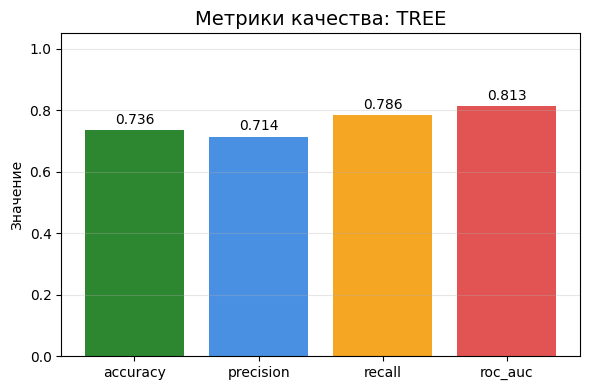

In [5]:
plt.figure(figsize=(6, 4))
names = list(metrics.keys())
values = list(metrics.values())
bars = plt.bar(names, values, color=['#2D8730', '#4A90E2', '#F5A623', '#E25353'])
plt.ylim(0, 1.05)
plt.title(f'Метрики качества: {model_name.upper()}', fontsize=14)
plt.ylabel('Значение')
plt.grid(axis='y', alpha=0.3)

# Подписи значений на столбцах
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'metrics_bar.png', dpi=300)
print("💾 График метрик сохранён")
plt.show()

💾 Матрица ошибок сохранена


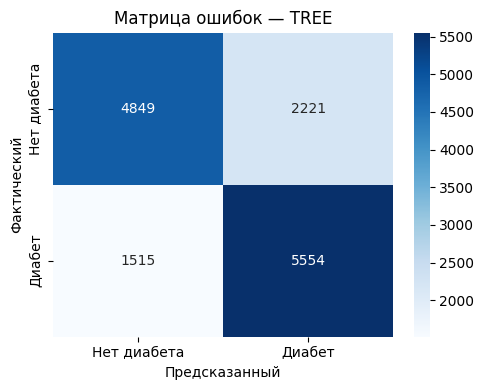

In [6]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет диабета', 'Диабет'],
            yticklabels=['Нет диабета', 'Диабет'])
plt.title(f'Матрица ошибок — {model_name.upper()}')
plt.ylabel('Фактический')
plt.xlabel('Предсказанный')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'confusion_final.png', dpi=300)
print("💾 Матрица ошибок сохранена")
plt.show()

💾 ROC-кривая сохранена


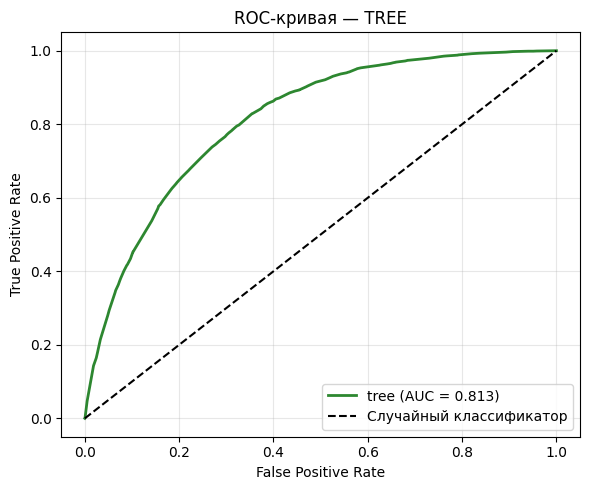

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})', linewidth=2, color='#2D8730')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-кривая — {model_name.upper()}')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'roc_final.png', dpi=300)
print("💾 ROC-кривая сохранена")
plt.show()

💾 Важность признаков Tree сохранена


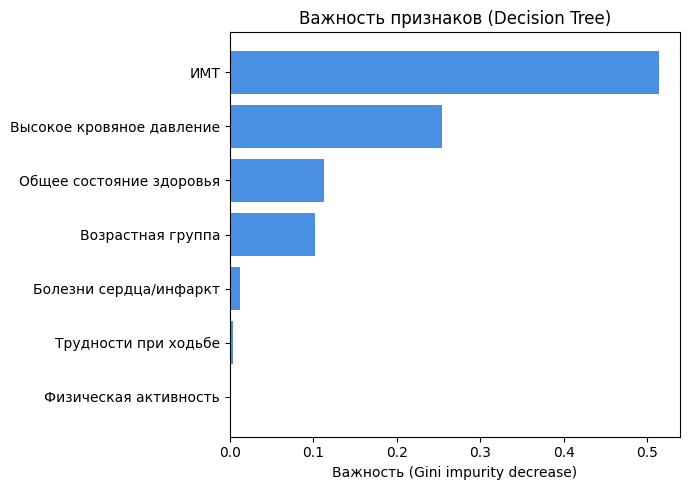

In [ ]:
if model_name == 'logistic':
    coef = model.coef_[0]
    odds_ratio = np.exp(coef)
    df_imp = pd.DataFrame({
        'feature': [FEATURE_LABELS.get(f, f) for f in package['features']],
        'coef': coef,
        'odds_ratio': odds_ratio
    }).sort_values('odds_ratio', ascending=False)

    plt.figure(figsize=(7, 5))
    colors = ['#2D8730' if o > 1 else '#9E2A22' for o in odds_ratio]
    plt.barh(df_imp['feature'], df_imp['coef'], color=colors)
    plt.axvline(0, color='gray', linestyle='--')
    plt.title('Влияние признаков на риск диабета (Logistic Regression)')
    plt.xlabel('Коэффициент (log-odds)')
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'logreg_coefs.png', dpi=300)
    print("💾 Коэффициенты LogReg сохранены")
    plt.show()

elif model_name == 'tree':
    imp = model.feature_importances_
    df_imp = pd.DataFrame({
        'feature': [FEATURE_LABELS.get(f, f) for f in package['features']],
        'importance': imp
    }).sort_values('importance', ascending=True)

    plt.figure(figsize=(7, 5))
    plt.barh(df_imp['feature'], df_imp['importance'], color='#4A90E2')
    plt.title('Важность признаков (Decision Tree)')
    plt.xlabel('Важность (Gini impurity decrease)')
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'tree_importance.png', dpi=300)
    print("💾 Важность признаков Tree сохранена")
    plt.show()